# Image Transformation


### Note:
- `img.shape: [height,width,color]` 
- `img.shape[0]` gives rows, Height (Y-axis)
- `img.shape[1]` gives column, width (X-axis)
- `img.shape[2]` gives depth, channels (BGR)

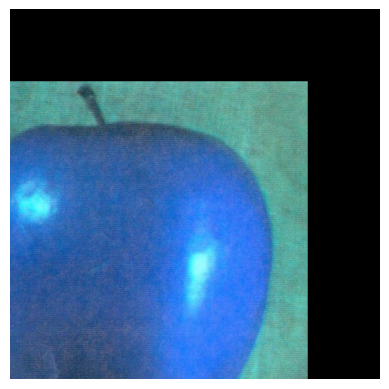

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img=cv.imread("../image/apple.jpg")

# Translation
def translate(img,x,y): # x,y are no of pixels
    transMat=np.float32([[1,0,x],[0,1,y]])
    dimensions=(img.shape[1],img.shape[0])
    return cv.warpAffine(img,transMat,dimensions)

# -x ---> left
# -y ---> Up
# x ---> right
# y ---> down

translated=translate(img,-100,100)

plt.imshow(translated)
plt.axis("off")
plt.show()  


```Text
Translation is important because it lets us move images or objects accurately, which is critical for alignment, data augmentation, preprocessing, and graphics.
Translation = move
Rotation    = turn
Scaling     = zoom
```

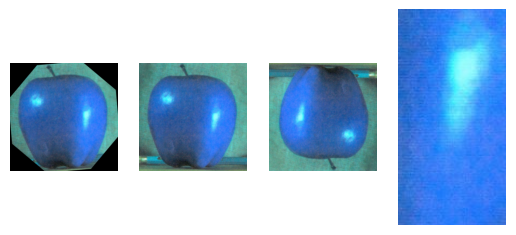

In [ ]:
# rotation
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img=cv.imread("../image/apple.jpg")

def rotate(img,angle,rotPoint=None):
    (height,width)= img.shape[:2] 


    if rotPoint is None: # assume that we are going to rotate around center
        rotPoint=(width//2,height//2)   #exact center of the image as the pivot point.
    rotMat=cv.getRotationMatrix2D(rotPoint,angle,1.0)
    dimensions=(width,height)

    return cv.warpAffine(img,rotMat,dimensions)

rotated=rotate(img,45)
unrotated=rotate(rotated,-40)


plt.subplot(1,4,1)
plt.imshow(unrotated)
plt.axis("off")
# resize

resized=cv.resize(img,(500,500),interpolation=cv.INTER_CUBIC)

plt.subplot(1,4,2)
plt.imshow(resized)
plt.axis("off")



# flipping

flip = cv.flip(img,-1)
plt.subplot(1,4,3)
plt.imshow(flip)
plt.axis("off")


# cropping
#              [  Rows (Height)  ,  Columns (Width)  ]
#              [  Start : End    ,   Start  : End    ]

cropped=img[200:400,300:400]
plt.subplot(1,4,4)
plt.imshow(cropped)
plt.axis("off")
plt.show()

```Text
cv.warpAffine takes the original picture, manipulates it according to  instructions, and pastes it onto the new blank paper.

Flipcode
1 = Horizontal Flip ↔️ (Mirror image / Left-to-Right)

0 = Vertical Flip ↕️ (Upside down / Top-to-Bottom)

-1 = Both Flips 🔄 (Upside down + Mirrored)